# LAB 03 — Spatial Cross-Validation

## Random K-Fold versus spatially blocked validation

This laboratory evaluates how validation design changes the apparent
predictive performance of a spatial model.

The experiment uses only controlled synthetic data. No real exploration,
assay, grade, deposit, or prospectivity data are used.

### Research question

**How much optimism can conventional random cross-validation introduce when
training and validation observations remain spatially close?**

The experiment holds the model and data-generating process fixed while
changing the validation strategy.

## Experimental design

The synthetic sampling process is inherited from LAB02 and contains:

- 800 observations
- 500 regional samples
- 300 campaign samples
- projected coordinates in EPSG:32719
- an observed synthetic spatial signal
- a noise-free synthetic signal retained only as a reference

The predictive baseline is a distance-weighted K-nearest-neighbours
regressor using only Easting and Northing.

The validation comparison is:

1. reproducible Random K-Fold;
2. spatial block cross-validation.

Block sizes of 5 km, 10 km, and 20 km are evaluated.

The **5 km design is the primary scenario** because its folds retain broad
spatial support. The 10 km and 20 km designs are retained as sensitivity
and stress-test scenarios.

In [1]:
%matplotlib inline

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
SRC_DIR = REPO_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from geoai.spatial import (
    DEFAULT_BOUNDS,
    DEFAULT_CRS,
    generate_synthetic_sampling,
)
from geoai.validation import (
    assign_spatial_blocks,
    spatial_group_kfold_indices,
)

LAB_DIR = REPO_ROOT / "labs" / "lab03_spatial_cross_validation"
RESULTS_DIR = LAB_DIR / "results"

PRIMARY_BLOCK_M = 5000.0
SENSITIVITY_BLOCKS_M = (10000.0, 20000.0)
SEED = 12345

print("LAB03_NOTEBOOK_SETUP = PASS")
print("Primary spatial block:", f"{PRIMARY_BLOCK_M / 1000:.0f} km")
print("CRS:", DEFAULT_CRS)

LAB03_NOTEBOOK_SETUP = PASS
Primary spatial block: 5 km
CRS: EPSG:32719


## 1. Load the persisted experiment

The numerical experiment was executed independently before this notebook was
built. The notebook reads the persisted outputs so that presentation and
scientific interpretation do not silently alter the experiment.

In [2]:
fold_results = pd.read_csv(RESULTS_DIR / "fold_results.csv")
aggregate_metrics = pd.read_csv(RESULTS_DIR / "aggregate_metrics.csv")
aggregate_comparison = pd.read_csv(
    RESULTS_DIR / "aggregate_comparison.csv"
)
scenario_diagnostics = pd.read_csv(
    RESULTS_DIR / "scenario_diagnostics.csv"
)

metadata = json.loads(
    (RESULTS_DIR / "experiment_metadata.json").read_text(
        encoding="utf-8"
    )
)

required_sizes = {5000.0, 10000.0, 20000.0}

assert set(aggregate_comparison["block_size_m"]) == required_sizes
assert metadata["n_samples"] == 800
assert metadata["seed"] == SEED

print("PERSISTED_RESULTS = VERIFIED")
print("Observations:", metadata["n_samples"])
print("CV folds:", metadata["n_splits"])
print("Model:", metadata["model"])
print("Neighbors:", metadata["n_neighbors"])

PERSISTED_RESULTS = VERIFIED
Observations: 800
CV folds: 5
Model: KNeighborsRegressor
Neighbors: 15


## 2. Reconstruct the controlled spatial dataset

The dataset is regenerated with the recorded seed. `signal` is the modelling
target. `signal_true` is retained only to understand the synthetic
data-generating process and is not supplied to the model.

In [3]:
frame = generate_synthetic_sampling(seed=SEED)

x = frame.geometry.x.to_numpy(dtype=float)
y = frame.geometry.y.to_numpy(dtype=float)

assert len(frame) == metadata["n_samples"]

frame[
    [
        "sample_id",
        "sampling_component",
        "signal_true",
        "signal",
    ]
].head()

,sample_id,sampling_component,signal_true,signal
0,S0001,regional,10.000000,15.480627
1,S0002,regional,10.000011,6.262295
2,S0003,regional,10.000000,12.893035
3,S0004,regional,10.000000,9.663387
4,S0005,regional,10.006110,7.958912


## 3. Primary spatial validation geometry — 5 km

Each 5 km spatial block is assigned wholly to one validation fold. This
prevents the same block from appearing simultaneously in training and
validation.

Spatial blocking reduces direct spatial information sharing; it does not
prove complete spatial independence.

In [4]:
primary_groups = assign_spatial_blocks(
    x,
    y,
    block_size=PRIMARY_BLOCK_M,
    origin_x=DEFAULT_BOUNDS[0],
    origin_y=DEFAULT_BOUNDS[2],
)

primary_splits = spatial_group_kfold_indices(
    primary_groups,
    n_splits=metadata["n_splits"],
)

sample_fold = np.empty(len(frame), dtype=int)

for split in primary_splits:
    sample_fold[split.test_idx] = split.fold

frame = frame.copy()
frame["spatial_fold_5km"] = sample_fold

print("Populated 5 km blocks:", np.unique(primary_groups).size)
print(
    "Samples per fold:",
    frame.groupby("spatial_fold_5km").size().to_dict(),
)

Populated 5 km blocks: 224
Samples per fold: {0: 160, 1: 160, 2: 160, 3: 160, 4: 160}


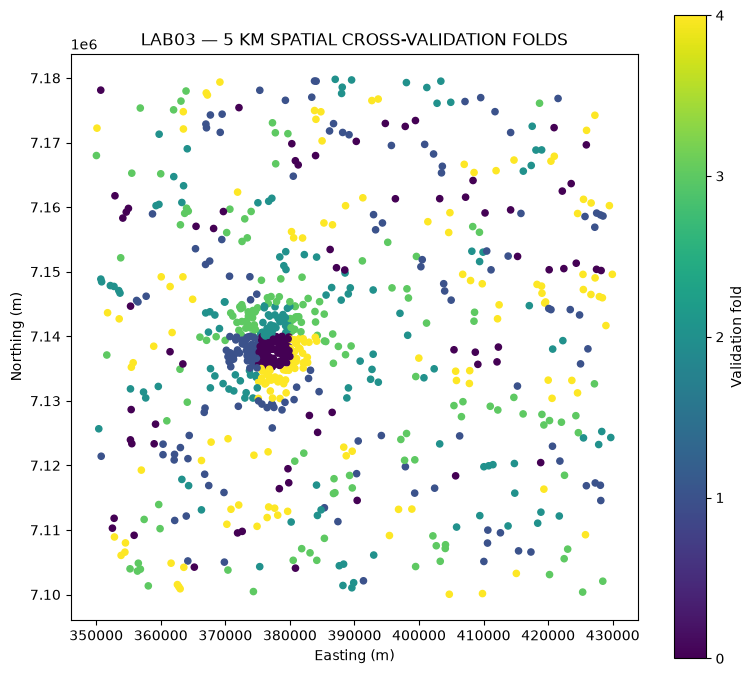

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))

points = ax.scatter(
    frame.geometry.x,
    frame.geometry.y,
    c=frame["spatial_fold_5km"],
    s=20,
)

ax.set_title("LAB03 — 5 KM SPATIAL CROSS-VALIDATION FOLDS")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")

colorbar = fig.colorbar(points, ax=ax)
colorbar.set_label("Validation fold")
colorbar.set_ticks(range(metadata["n_splits"]))

plt.tight_layout()
plt.show()

## 4. Primary comparison — Random CV versus 5 km Spatial CV

RMSE and MAE are treated as the primary performance metrics.

R² is reported as a complementary diagnostic because spatial folds may have
very different target variance. Under low within-fold variance, R² can become
unstable or negative even when absolute prediction error remains moderate.

In [6]:
primary = aggregate_comparison.loc[
    aggregate_comparison["block_size_m"] == PRIMARY_BLOCK_M
].iloc[0]

primary_table = pd.DataFrame(
    {
        "Metric": [
            "Pooled RMSE",
            "Pooled MAE",
            "Median test-to-train separation (m)",
        ],
        "Random K-Fold": [
            primary["random_pooled_rmse"],
            primary["random_pooled_mae"],
            primary["random_median_separation_m"],
        ],
        "Spatial CV — 5 km": [
            primary["spatial_pooled_rmse"],
            primary["spatial_pooled_mae"],
            primary["spatial_median_separation_m"],
        ],
    }
)

primary_table.round(3)

,Metric,Random K-Fold,Spatial CV — 5 km
0,Pooled RMSE,3.968,4.261
1,Pooled MAE,2.807,2.962
2,Median test-to-train separation (m),1107.709,2387.713


In [7]:
print(
    "Random pooled RMSE:",
    f"{primary['random_pooled_rmse']:.4f}",
)
print(
    "Spatial pooled RMSE:",
    f"{primary['spatial_pooled_rmse']:.4f}",
)
print(
    "Relative RMSE optimism:",
    f"{primary['relative_rmse_optimism_pct']:.2f}%",
)
print(
    "Random median separation:",
    f"{primary['random_median_separation_m'] / 1000:.2f} km",
)
print(
    "Spatial median separation:",
    f"{primary['spatial_median_separation_m'] / 1000:.2f} km",
)

Random pooled RMSE: 3.9676
Spatial pooled RMSE: 4.2610
Relative RMSE optimism: 6.89%
Random median separation: 1.11 km
Spatial median separation: 2.39 km


### Interpretation

In the primary controlled scenario, Random K-Fold evaluates observations that
remain geographically closer to their training data. Spatial blocking
increases this separation and produces a more demanding estimate of
generalization.

The result should be interpreted as evidence for this synthetic experiment
and this fixed local model, not as a universal correction factor for spatial
machine learning.

## 5. Sensitivity to spatial block size

Larger blocks make validation increasingly spatially restrictive, but they
also reduce the number of independent spatial units available to distribute
across folds.

For this reason, stronger performance degradation at larger block sizes
cannot be interpreted only as "more leakage removed"; fold support and target
heterogeneity must also be examined.

In [8]:
comparison_display = aggregate_comparison[
    [
        "block_size_m",
        "random_pooled_rmse",
        "spatial_pooled_rmse",
        "relative_rmse_optimism_pct",
        "random_median_separation_m",
        "spatial_median_separation_m",
    ]
].copy()

comparison_display["block_size_km"] = (
    comparison_display["block_size_m"] / 1000
)

comparison_display[
    [
        "block_size_km",
        "random_pooled_rmse",
        "spatial_pooled_rmse",
        "relative_rmse_optimism_pct",
        "random_median_separation_m",
        "spatial_median_separation_m",
    ]
].round(3)

,block_size_km,random_pooled_rmse,spatial_pooled_rmse,relative_rmse_optimism_pct,random_median_separation_m,spatial_median_separation_m
0,5.0,3.968,4.261,6.885,1107.709,2387.713
1,10.0,3.968,5.087,21.999,1107.709,3192.453
2,20.0,3.968,5.232,24.167,1107.709,5413.619


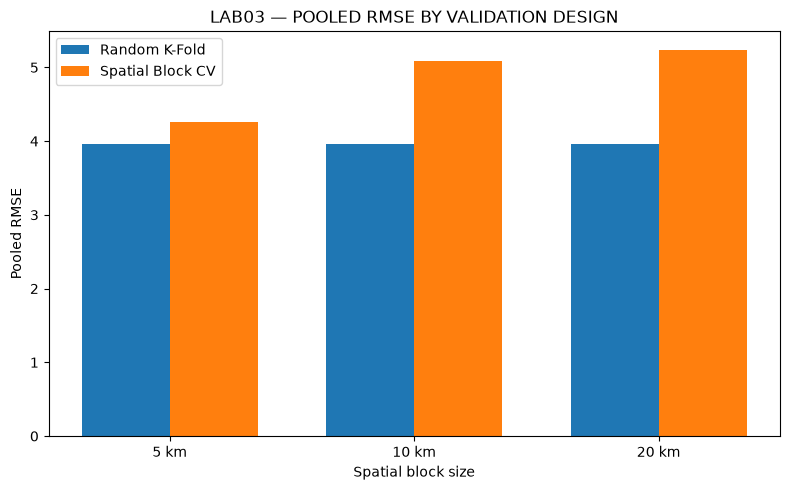

In [9]:
plot_data = aggregate_comparison.copy()
labels = [
    f"{value / 1000:.0f} km"
    for value in plot_data["block_size_m"]
]

positions = np.arange(len(plot_data))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    positions - width / 2,
    plot_data["random_pooled_rmse"],
    width,
    label="Random K-Fold",
)
ax.bar(
    positions + width / 2,
    plot_data["spatial_pooled_rmse"],
    width,
    label="Spatial Block CV",
)

ax.set_title("LAB03 — POOLED RMSE BY VALIDATION DESIGN")
ax.set_xlabel("Spatial block size")
ax.set_ylabel("Pooled RMSE")
ax.set_xticks(positions, labels)
ax.legend()

plt.tight_layout()
plt.show()

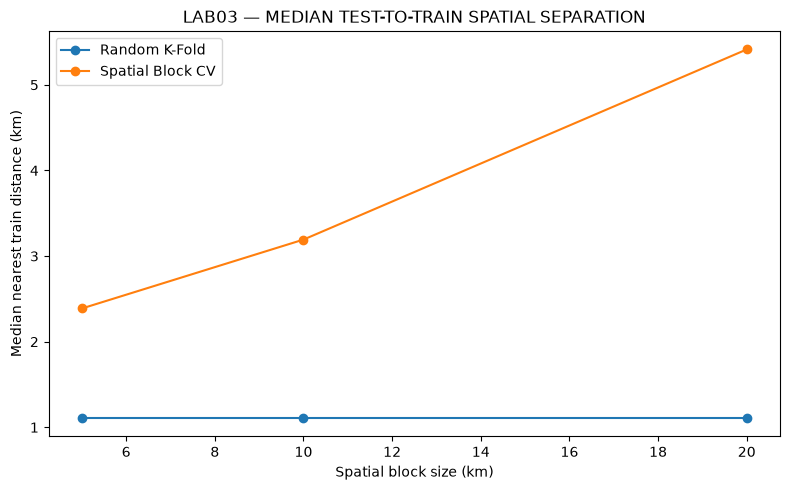

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    plot_data["block_size_m"] / 1000,
    plot_data["random_median_separation_m"] / 1000,
    marker="o",
    label="Random K-Fold",
)
ax.plot(
    plot_data["block_size_m"] / 1000,
    plot_data["spatial_median_separation_m"] / 1000,
    marker="o",
    label="Spatial Block CV",
)

ax.set_title("LAB03 — MEDIAN TEST-TO-TRAIN SPATIAL SEPARATION")
ax.set_xlabel("Spatial block size (km)")
ax.set_ylabel("Median nearest train distance (km)")
ax.legend()

plt.tight_layout()
plt.show()

## 6. Fold stability

A validation strategy should not be judged only from its mean score. Fold
dispersion helps identify whether the apparent performance estimate is being
driven by particular spatial regions.

In [11]:
primary_folds = fold_results[
    fold_results["block_size_m"] == PRIMARY_BLOCK_M
].copy()

fold_rmse = primary_folds.pivot(
    index="fold",
    columns="strategy",
    values="rmse",
)

fold_rmse.round(3)

strategy,random_kfold,spatial_block
fold,,
0,4.084,5.204
1,3.824,4.019
2,3.959,3.741
3,4.291,3.639
4,3.650,4.507


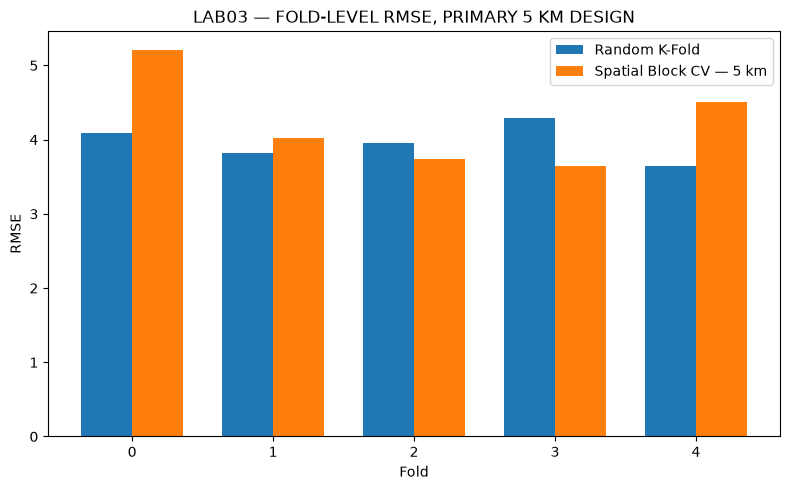

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

positions = np.arange(len(fold_rmse))
width = 0.36

ax.bar(
    positions - width / 2,
    fold_rmse["random_kfold"],
    width,
    label="Random K-Fold",
)
ax.bar(
    positions + width / 2,
    fold_rmse["spatial_block"],
    width,
    label="Spatial Block CV — 5 km",
)

ax.set_title("LAB03 — FOLD-LEVEL RMSE, PRIMARY 5 KM DESIGN")
ax.set_xlabel("Fold")
ax.set_ylabel("RMSE")
ax.set_xticks(positions, fold_rmse.index)
ax.legend()

plt.tight_layout()
plt.show()

## 7. Why 5 km is the primary scenario

The selection is based on validation support, not on choosing the result that
best matches the hypothesis.

At 5 km, all five folds retain many populated blocks and balanced sample
counts. At 10 km and 20 km, one or more folds can be dominated by a single
large block with almost no variation in the underlying synthetic signal.

Those coarser designs remain informative stress tests, but they provide less
stable fold-level inference.

In [13]:
scenario_diagnostics.assign(
    block_size_km=scenario_diagnostics["block_size_m"] / 1000
)[
    [
        "block_size_km",
        "populated_blocks",
        "min_test_blocks",
        "max_test_blocks",
        "median_test_blocks",
        "min_test_n",
        "max_test_n",
        "min_signal_true_sd",
        "max_signal_true_sd",
    ]
].round(3)

,block_size_km,populated_blocks,min_test_blocks,max_test_blocks,median_test_blocks,min_test_n,max_test_n,min_signal_true_sd,max_signal_true_sd
0,5.0,224,37,48,46.0,160,160,5.795,11.509
1,10.0,64,1,18,16.0,155,178,0.000,14.229
2,20.0,16,1,5,4.0,129,239,0.000,14.997


## 8. Methodological limitations

This laboratory intentionally isolates one methodological issue.

The conclusions are bounded by the following conditions:

- the data are synthetic;
- the target is a controlled smooth spatial signal plus noise;
- the model is a fixed KNN baseline;
- coordinates are the only predictive features;
- regular grid blocking is used;
- no spatial buffer is applied between train and validation samples;
- only one realization of the primary predictive experiment is presented;
- the experiment does not estimate mineral prospectivity.

More advanced spatial validation designs may include buffers, leave-location-
out schemes, geological-domain grouping, repeated spatial partitions, or
nested spatial cross-validation.

## 9. Conclusion

LAB03 demonstrates why validation design is part of the scientific model
rather than merely an implementation detail.

For the primary 5 km scenario, spatial blocking eliminates direct block
overlap between training and validation, increases geographic separation,
and produces a higher pooled prediction error than Random K-Fold.

The 10 km and 20 km experiments show that increasingly coarse spatial
blocking can produce an even more demanding test, but also reduce effective
spatial support and destabilize fold-level metrics such as R².

Therefore, model performance in spatial machine learning should always be
interpreted together with the geometry and support of the validation design.

In [14]:
primary_diag = scenario_diagnostics.loc[
    scenario_diagnostics["block_size_m"] == PRIMARY_BLOCK_M
].iloc[0]

assert primary_diag["min_test_blocks"] >= 30
assert primary_diag["min_test_n"] == primary_diag["max_test_n"] == 160

spatial_primary = aggregate_metrics[
    (aggregate_metrics["block_size_m"] == PRIMARY_BLOCK_M)
    & (aggregate_metrics["strategy"] == "spatial_block")
].iloc[0]

assert spatial_primary["mean_group_overlap"] == 0.0

print("PRIMARY_SCENARIO = 5 km")
print(
    "RMSE optimism relative to Spatial CV:",
    f"{primary['relative_rmse_optimism_pct']:.2f}%",
)
print(
    "Spatial fold block overlap:",
    int(spatial_primary["mean_group_overlap"]),
)
print("LAB03_NOTEBOOK_VALIDATION = PASS")

PRIMARY_SCENARIO = 5 km
RMSE optimism relative to Spatial CV: 6.89%
Spatial fold block overlap: 0
LAB03_NOTEBOOK_VALIDATION = PASS
